In [12]:
import pandas as pd

# Load the data and skip any 'broken' lines
data = pd.read_csv('data.csv', on_bad_lines='skip') #on_bad_lines = to ignore the row in the dataset which is malformed.

# Drop any rows that are empty (NaN)
data.dropna(inplace=True) 

# Show the first 5 rows and the count of each strength (0, 1, 2)
print(data.head())
print("\nPassword Strength Counts:")
print(data['strength'].value_counts()) #select the column strength and then print the number of time each label is appearing. 

      password  strength
0     kzde5577         1
1     kino3434         1
2    visi7k1yr         1
3     megzy123         1
4  lamborghin1         1

Password Strength Counts:
strength
1    496801
0     89701
2     83137
Name: count, dtype: int64


### Downsampling the dataset
Because it is not consistent - bring down the value of medium passwords to 100k from ~500k.


In [13]:
# Separate the data by strength
df_0 = data[data['strength'] == 0]
df_1 = data[data['strength'] == 1]
df_2 = data[data['strength'] == 2]

# Downsample the 'Medium' (1) group to 100,000 samples
df_1_downsampled = df_1.sample(n=100000, random_state=42)

# Combine them back into one balanced dataset
data_balanced = pd.concat([df_0, df_1_downsampled, df_2])

# Shuffle the new dataset so the model doesn't see all 0s then all 1s
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the new counts
print("Balanced Strength Counts:")
print(data_balanced['strength'].value_counts())

Balanced Strength Counts:
strength
1    100000
0     89701
2     83137
Name: count, dtype: int64


### Train Test Split:

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer   #TfidfVectorizer is used to convert texts into numeric feature vectors. 

# 1. Define X (features/passwords) and y (target/strength)
X = data_balanced['password'].values.astype('U') # 'U' ensures all are strings #values converts them into a single array
y = data_balanced['strength'].values  

# 2. The Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Turn passwords into numbers using TF-IDF (Character-level)
# We use analyzer='char' because passwords don't have "words"
vectorizer = TfidfVectorizer(analyzer='char') #character level analyzer 

# Train the vectorizer on the training data only 
X_train_tfidf = vectorizer.fit_transform(X_train)  #'fit' learns the vocabulary of character from training data. transform() converts pswds into numerical vectors.

# Transform the test data (don't "fit" here, just "transform")  
X_test_tfidf = vectorizer.transform(X_test)   

print(f"Training set size: {X_train_tfidf.shape}")  
print(f"Testing set size: {X_test_tfidf.shape}")  

Training set size: (218270, 136)
Testing set size: (54568, 136)


### Training Phase : Random Forest Classifier

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the model
# n_estimators=100 means we use 100 "decision trees" to vote on the result
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# 2. Train the model (The "Studying" phase)
# This might take a minute depending on your laptop's speed
model.fit(X_train_tfidf, y_train)

# 3. Predict on the Test set (The "Final Exam")
y_pred = model.predict(X_test_tfidf)

Checking the results.

In [16]:
# 4. Print the Accuracy
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 5. Print a detailed report
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 95.10%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     18176
           1       0.94      0.93      0.93     19827
           2       0.97      0.97      0.97     16565

    accuracy                           0.95     54568
   macro avg       0.95      0.95      0.95     54568
weighted avg       0.95      0.95      0.95     54568



Test with my own passwords.

In [17]:
def predict_password(my_password):
    # Vectorize the input
    test_data = vectorizer.transform([my_password])
    # Predict
    res = model.predict(test_data)
    
    strength = {0: "Weak", 1: "Medium", 2: "Strong"}
    print(f"The password '{my_password}' is: {strength[res[0]]}")

# Example tests
predict_password("123456")
predict_password("abhishree_raj_2026")
predict_password("P@ssw0rd!#99")

The password '123456' is: Weak
The password 'abhishree_raj_2026' is: Strong
The password 'P@ssw0rd!#99' is: Strong


Training with Linear Regression to understand the accuracy with different mmodel

In [21]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize Logistic Regression (Updated to avoid the TypeError)
log_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# 2. Train the model
log_model.fit(X_train_tfidf, y_train)

# 3. Predict and check accuracy
y_pred_log = log_model.predict(X_test_tfidf)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log) * 100:.2f}%")

Logistic Regression Accuracy: 79.66%


Training with Decision Tree:

In [20]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree
# We use random_state=42 so you get the same results every time
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Train the model
# This is usually much faster than Random Forest
dt_model.fit(X_train_tfidf, y_train)

# 3. Predict and check accuracy
y_pred_dt = dt_model.predict(X_test_tfidf)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%")

Decision Tree Accuracy: 89.12%


### Confusion Matrix

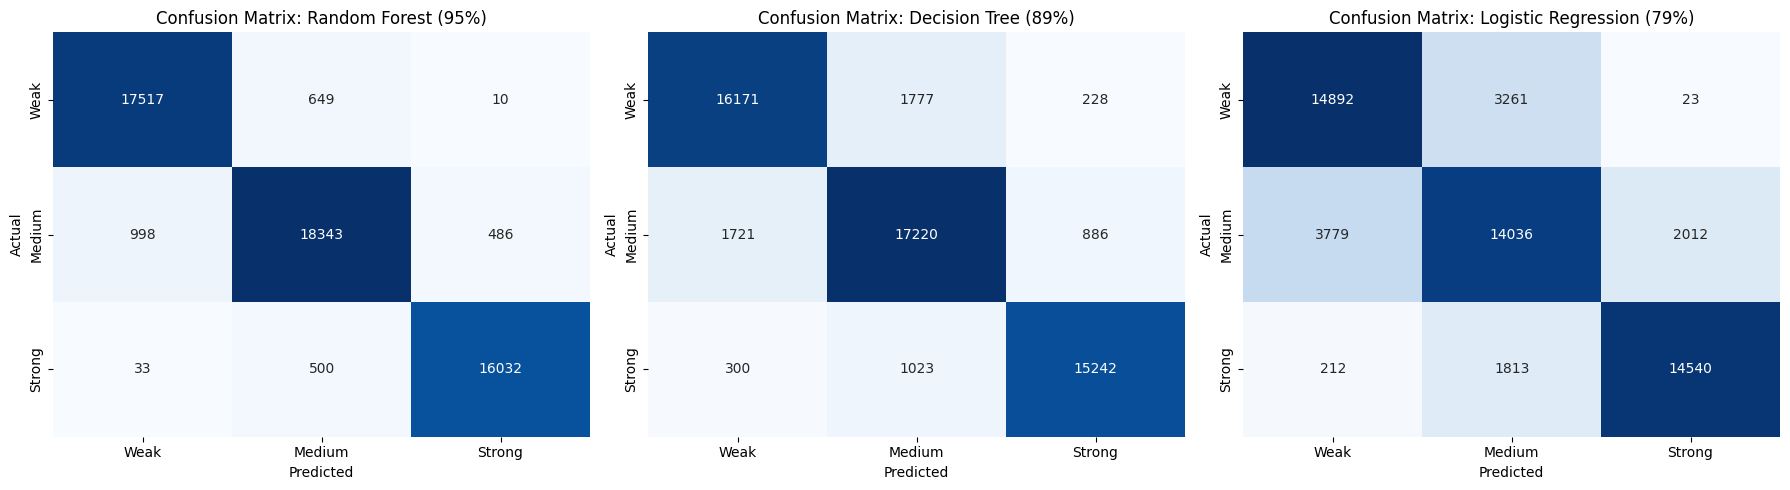

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# List of models and their predictions
models = [model, dt_model, log_model]
model_names = ['Random Forest (95%)', 'Decision Tree (89%)', 'Logistic Regression (79%)']
predictions = [y_pred, y_pred_dt, y_pred_log]

# Create the figure
plt.figure(figsize=(18, 5))

for i in range(3):
    plt.subplot(1, 3, i+1)
    cm = confusion_matrix(y_test, predictions[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Weak', 'Medium', 'Strong'],
                yticklabels=['Weak', 'Medium', 'Strong'])
    plt.title(f'Confusion Matrix: {model_names[i]}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

### Model Saving for deployment.

In [24]:
import joblib

# Save the Random Forest model
joblib.dump(model, 'random_forest_model.pkl')

# Save the TF-IDF vectorizer (This is crucial for the app to 'understand' text)
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Files saved! You are now ready to build the web app.")

Files saved! You are now ready to build the web app.
